# SVM com o dataset Iris — versão descritiva para aula

Este notebook foi elaborado como **material de apoio didático** para uma aula introdutória de **aprendizado de máquina**, com foco em **classificação supervisionada** e no algoritmo **Support Vector Machine (SVM)**.

A proposta aqui não é apenas executar código, mas **entender o raciocínio por trás de cada etapa**.  
Por isso, o notebook foi escrito de forma bastante descritiva, com explicações em linguagem acessível, observações conceituais e pequenas interpretações ao longo do caminho.

## Objetivos da aula

Ao final desta atividade, espera-se que o estudante consiga:

- compreender o que é um problema de classificação supervisionada;
- identificar as variáveis de entrada e a variável-alvo em um dataset;
- entender a ideia geral do algoritmo SVM;
- reconhecer a importância do pré-processamento, especialmente da padronização;
- treinar e avaliar um classificador SVM;
- comparar configurações lineares e não lineares;
- interpretar métricas de desempenho;
- responder questões de fixação com base nos resultados obtidos.

## Estrutura do notebook

Este material está dividido em seis blocos:

1. contexto teórico;
2. apresentação do dataset Iris;
3. exploração e preparação dos dados;
4. treinamento de um SVM linear;
5. treinamento de um SVM não linear;
6. questões de fixação e propostas de extensão.

> A recomendação é executar as células na ordem.


## 1. Introdução: o que é aprendizado de máquina supervisionado?

Em aprendizado de máquina supervisionado, trabalhamos com exemplos já conhecidos.  
Cada exemplo possui um conjunto de características numéricas ou categóricas, chamadas de **variáveis de entrada**, e um rótulo correto, chamado de **variável-alvo**.

O objetivo é treinar um modelo para aprender a relação entre as entradas e a saída.  
Depois disso, o modelo pode ser usado para prever a classe de novas amostras que ele ainda não viu.

### Exemplo intuitivo

Imagine que temos medidas de flores e sabemos, para várias delas, a espécie correta.  
Se fornecermos essas medidas ao algoritmo junto com os rótulos, ele tentará aprender padrões que ajudem a distinguir uma espécie da outra.

Esse é exatamente o caso do **dataset Iris**, que será usado neste notebook.


## 2. O dataset Iris

O **Iris dataset** é um dos mais famosos da história da estatística e da ciência de dados.  
Ele foi popularizado por **Ronald A. Fisher** em 1936 e desde então se tornou um exemplo clássico para ensino de classificação.

O conjunto contém **150 amostras de flores**, divididas igualmente em três espécies:

- *setosa*
- *versicolor*
- *virginica*

Para cada flor, temos quatro medidas:

- comprimento da sépala
- largura da sépala
- comprimento da pétala
- largura da pétala

Assim, nosso problema será:

> **a partir das medidas morfológicas da flor, prever sua espécie**.

Esse dataset é muito usado em aula porque:

- é pequeno e fácil de manipular;
- tem classes balanceadas;
- permite visualizações intuitivas;
- gera bons resultados com algoritmos clássicos;
- facilita a compreensão de conceitos fundamentais.


## 3. O que é SVM?

**SVM** significa **Support Vector Machine**.

Esse algoritmo procura construir uma fronteira de decisão que separe as classes da melhor maneira possível.  
No caso mais simples, essa fronteira é uma reta ou um plano. Em dimensões maiores, chamamos essa fronteira de **hiperplano**.

A ideia central do SVM é encontrar o hiperplano que maximize a **margem**, isto é, a distância entre a fronteira e os pontos mais próximos de cada classe.

Esses pontos mais próximos são chamados de **vetores de suporte**.

### Por que isso é interessante?

Porque uma separação com margem maior tende a ser mais robusta para generalização.

### Dois cenários importantes

#### SVM linear
É usado quando uma separação aproximadamente linear entre as classes é suficiente.

#### SVM não linear
É usado quando a separação entre as classes exige fronteiras mais flexíveis.  
Nesses casos, usamos um **kernel**, como o `rbf`, para permitir decisões mais complexas.

### Parâmetros importantes

- `C`: controla o quanto o modelo tolera erros de classificação no treino;
- `kernel`: define o tipo de fronteira;
- `gamma`: importante em kernels não lineares, pois controla o alcance da influência dos pontos.

Neste notebook, vamos comparar um **SVM linear** com um **SVM não linear**.


## 4. Importação das bibliotecas

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.figsize"] = (8, 5)

As bibliotecas acima serão usadas para:

- carregar o dataset;
- manipular os dados;
- dividir treino e teste;
- padronizar variáveis;
- treinar modelos SVM;
- calcular métricas;
- produzir gráficos e matrizes de confusão.


## 5. Carregando o dataset Iris

In [4]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species_id")

species_names = {i: name for i, name in enumerate(iris.target_names)}

df = X.copy()
df["species_id"] = y
df["species"] = df["species_id"].map(species_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


A tabela acima mostra as primeiras linhas do conjunto de dados.  
Observe que cada linha representa uma flor, e cada coluna numérica representa uma medida morfológica.

A coluna `species` será nossa variável-alvo em formato legível.


## 6. Conhecendo a estrutura dos dados

In [5]:
print("Dimensão do dataset:", df.shape)
print("\nNomes das colunas:")
for col in df.columns:
    print("-", col)

print("\nContagem por espécie:")
print(df["species"].value_counts())

Dimensão do dataset: (150, 6)

Nomes das colunas:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)
- species_id
- species

Contagem por espécie:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [6]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Interpretação desta etapa

A saída mostra que:

- o dataset possui **150 linhas**;
- temos **4 variáveis numéricas principais**;
- existem **3 classes**;
- cada espécie tem **50 amostras**, o que significa que o conjunto é balanceado.

Esse equilíbrio é muito útil em ensino, porque evita problemas adicionais causados por desbalanceamento de classes.


## 7. Exploração visual

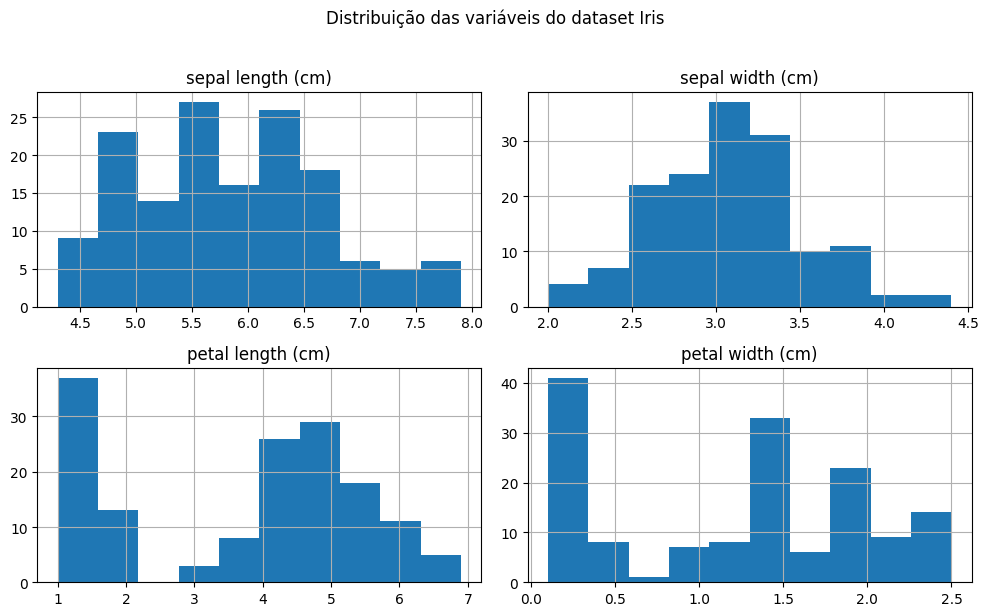

In [7]:
df[X.columns].hist(figsize=(10, 6))
plt.suptitle("Distribuição das variáveis do dataset Iris", y=1.02)
plt.tight_layout()
plt.show()

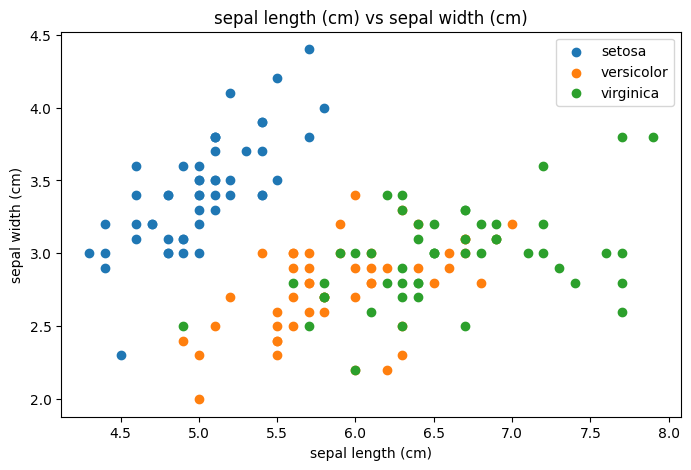

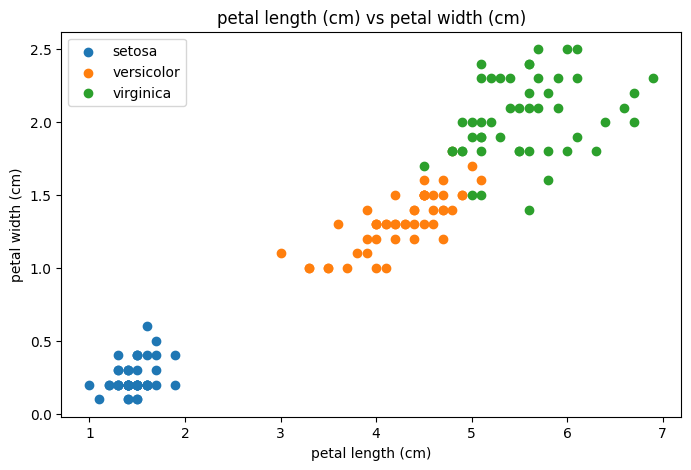

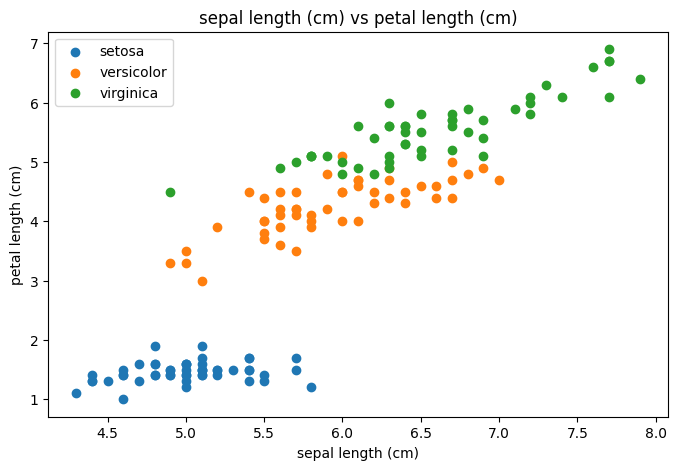

In [8]:
pairs = [
    ("sepal length (cm)", "sepal width (cm)"),
    ("petal length (cm)", "petal width (cm)"),
    ("sepal length (cm)", "petal length (cm)")
]

for xcol, ycol in pairs:
    plt.figure()
    for species in df["species"].unique():
        subset = df[df["species"] == species]
        plt.scatter(subset[xcol], subset[ycol], label=species)
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"{xcol} vs {ycol}")
    plt.legend()
    plt.show()

### O que observar nos gráficos?

Ao inspecionar os gráficos de dispersão, geralmente percebemos que:

- a espécie **setosa** tende a ficar bem separada das demais;
- **versicolor** e **virginica** apresentam maior sobreposição;
- as variáveis relacionadas às **pétalas** costumam ser muito informativas.

Essa etapa é importante porque mostra que a análise de dados começa antes do modelo.  
Visualizar ajuda a formular hipóteses e interpretar depois os resultados do algoritmo.


## 8. Definindo entradas e saída

In [9]:
X = df[iris.feature_names]
y = df["species"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (150, 4)
Formato de y: (150,)


Aqui definimos:

- `X`: matriz com as medidas das flores;
- `y`: vetor com a espécie correspondente de cada amostra.


## 9. Dividindo os dados em treino e teste

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nDistribuição em y_train:")
print(y_train.value_counts())
print("\nDistribuição em y_test:")
print(y_test.value_counts())

X_train: (120, 4)
X_test : (30, 4)

Distribuição em y_train:
species
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64

Distribuição em y_test:
species
setosa        10
virginica     10
versicolor    10
Name: count, dtype: int64


### Por que fazemos essa divisão?

Não devemos avaliar o modelo nos mesmos dados usados para treiná-lo, porque isso pode gerar uma falsa impressão de desempenho elevado.

A divisão treino/teste permite verificar se o modelo realmente generaliza para dados não vistos.


## 10. Padronização dos dados

Antes de treinar o SVM, precisamos discutir a **padronização**.

O SVM é sensível à escala das variáveis.  
Mesmo quando as diferenças de escala não parecem enormes, a padronização ainda é uma boa prática.

A maneira mais segura de fazer isso é com um **Pipeline**, que garante que:

- o `StandardScaler` seja ajustado usando apenas os dados de treino;
- a mesma transformação seja aplicada ao teste;
- o fluxo fique organizado e sem vazamento de dados.


## 11. Experimento 1 — SVM linear

Começaremos com um **SVM linear**.

Isso é importante didaticamente porque a versão linear é mais simples de entender e costuma ser uma boa porta de entrada para o algoritmo.


In [11]:
pipeline_svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0, random_state=42))
])

pipeline_svm_linear.fit(X_train, y_train)

y_pred_linear = pipeline_svm_linear.predict(X_test)

acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Acurácia do SVM linear: {acc_linear:.4f}")

Acurácia do SVM linear: 1.0000


In [12]:
print("Relatório de classificação — SVM linear\n")
print(classification_report(y_test, y_pred_linear))

Relatório de classificação — SVM linear

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



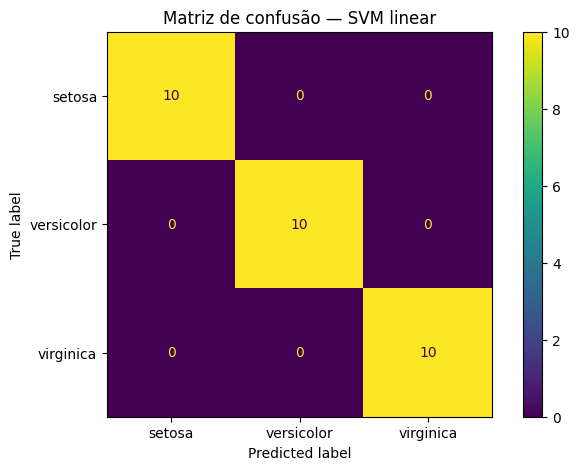

In [13]:
cm_linear = confusion_matrix(y_test, y_pred_linear, labels=iris.target_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=iris.target_names)
disp.plot()
plt.title("Matriz de confusão — SVM linear")
plt.show()

### Interpretação do SVM linear

Nesta etapa, observe:

- a acurácia global;
- se alguma espécie foi confundida com outra;
- quais classes parecem mais fáceis ou mais difíceis de separar.

Como o Iris é um conjunto relativamente simples, o SVM linear já pode apresentar excelente desempenho.


## 12. Validação cruzada do SVM linear

In [14]:
scores_linear = cross_val_score(pipeline_svm_linear, X, y, cv=5)

print("Acurácia em cada fold:", scores_linear)
print(f"Média: {scores_linear.mean():.4f}")
print(f"Desvio-padrão: {scores_linear.std():.4f}")

Acurácia em cada fold: [0.96666667 1.         0.93333333 0.93333333 1.        ]
Média: 0.9667
Desvio-padrão: 0.0298


A validação cruzada ajuda a verificar se o bom desempenho observado não depende apenas de uma divisão específica entre treino e teste.


## 13. Experimento 2 — SVM não linear com kernel RBF

Agora vamos repetir a análise com um **kernel não linear**, o `rbf`.

Esse kernel é muito usado porque consegue modelar fronteiras mais flexíveis.  
Em muitos problemas, isso melhora a capacidade de separação quando a estrutura entre as classes não é bem representada por uma fronteira linear.


In [15]:
pipeline_svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

pipeline_svm_rbf.fit(X_train, y_train)

y_pred_rbf = pipeline_svm_rbf.predict(X_test)

acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Acurácia do SVM com kernel RBF: {acc_rbf:.4f}")

Acurácia do SVM com kernel RBF: 0.9667


In [16]:
print("Relatório de classificação — SVM com kernel RBF\n")
print(classification_report(y_test, y_pred_rbf))

Relatório de classificação — SVM com kernel RBF

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



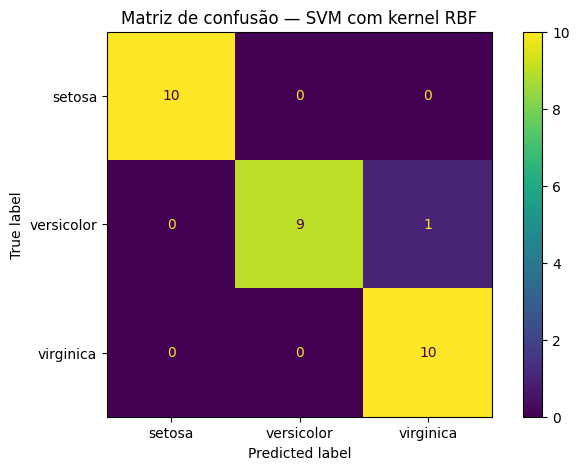

In [17]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf, labels=iris.target_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=iris.target_names)
disp.plot()
plt.title("Matriz de confusão — SVM com kernel RBF")
plt.show()

## 14. Validação cruzada do SVM com kernel RBF

In [18]:
scores_rbf = cross_val_score(pipeline_svm_rbf, X, y, cv=5)

print("Acurácia em cada fold:", scores_rbf)
print(f"Média: {scores_rbf.mean():.4f}")
print(f"Desvio-padrão: {scores_rbf.std():.4f}")

Acurácia em cada fold: [0.96666667 0.96666667 0.96666667 0.93333333 1.        ]
Média: 0.9667
Desvio-padrão: 0.0211


## 15. Comparação entre os modelos

In [19]:
comparacao = pd.DataFrame({
    "Modelo": ["SVM linear", "SVM não linear (RBF)"],
    "Acurácia no teste": [acc_linear, acc_rbf],
    "Acurácia média CV": [scores_linear.mean(), scores_rbf.mean()],
    "Desvio-padrão CV": [scores_linear.std(), scores_rbf.std()]
})

comparacao

,Modelo,Acurácia no teste,Acurácia média CV,Desvio-padrão CV
0,SVM linear,1.000000,0.966667,0.029814
1,SVM não linear (RBF),0.966667,0.966667,0.021082


### Perguntas para orientar a comparação

Ao observar a tabela, pergunte-se:

- qual modelo teve maior acurácia no conjunto de teste?
- qual apresentou melhor média na validação cruzada?
- houve diferença relevante entre eles?
- o ganho de complexidade do modelo não linear se justificou?

Essas perguntas são importantes porque, em ciência de dados, não basta escolher o modelo mais sofisticado: é preciso avaliar se ele realmente traz vantagem.


## 16. Atividade guiada — rodar com outros kernels não lineares

Agora que você já executou o kernel `rbf`, faça também experimentos com outras configurações.

### Tarefa 1 — testar kernel polinomial

Substitua a definição do modelo por algo como:

```python
Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly", degree=3, C=1.0, gamma="scale", random_state=42))
])
```

Depois:

- treine o modelo;
- calcule a acurácia;
- gere a matriz de confusão;
- compare com os resultados do kernel linear e do `rbf`.

### Tarefa 2 — testar diferentes valores de `C`

Repita o experimento do kernel `rbf` usando:

- `C = 0.1`
- `C = 1`
- `C = 10`
- `C = 100`

Anote:

- qual valor gerou o melhor desempenho;
- se o comportamento foi muito sensível a essa mudança.

### Tarefa 3 — testar diferentes valores de `gamma`

No kernel `rbf`, teste:

- `gamma="scale"`
- `gamma="auto"`
- `gamma=0.1`
- `gamma=1`

Discuta como essas alterações podem deixar a fronteira mais simples ou mais complexa.

### Espaço para execução

Nas células a seguir, use este espaço para seus próprios testes.


In [33]:
# EXERCÍCIO PRÁTICO 1
# Substitua e teste um kernel polinomial aqui.

# Exemplo de ponto de partida:
# pipeline_svm_poly = Pipeline([
#     ("scaler", StandardScaler()),
#     ("svm", SVC(kernel="poly", degree=3, C=1.0, gamma="scale", random_state=42))
# ])
#
# pipeline_svm_poly.fit(X_train, y_train)
# y_pred_poly = pipeline_svm_poly.predict(X_test)
# print("Acurácia:", accuracy_score(y_test, y_pred_poly))

pipeline_svm_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel = "poly", degree = 3, C = 1.0, gamma = "scale", random_state = 42))
])

pipeline_svm_poly.fit(X_train, y_train)
y_pred_poly = pipeline_svm_poly.predict(X_test)
print("Precisão do SVM (Kernel Poly degree = 3):", accuracy_score(y_test, y_pred_poly))

Precisão do SVM (Kernel Poly degree = 3): 0.9


In [30]:
# EXERCÍCIO PRÁTICO 2
# Teste diferentes valores de C no kernel RBF.

val_c = [0.1, 1, 10, 100]

for c in val_c:
  pipe = Pipeline([
      ("scaler", StandardScaler()),
      ("svm", SVC(kernel = "rbf", C = c, gamma = "scale", random_state = 42))
  ])

  pipe.fit(X_train, y_train)
  acc = accuracy_score(y_test, pipe.predict(X_test))
  print(f"Kernel RBF | C = {c:<5} -> Precisão: {acc:.4f}")

Kernel RBF | C = 0.1   -> Precisão: 0.9000
Kernel RBF | C = 1     -> Precisão: 0.9667
Kernel RBF | C = 10    -> Precisão: 0.9667
Kernel RBF | C = 100   -> Precisão: 0.9667


In [31]:
# EXERCÍCIO PRÁTICO 3
# Teste diferentes valores de gamma no kernel RBF.

val_g = ["scale", "auto", 0.1, 1]

for g in val_g:
  pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel = "rbf", C = 1.0, gamma = g, random_state = 42))
  ])
  pipe.fit(X_train, y_train)
  acc = accuracy_score(y_test, pipe.predict(X_test))
  print(f"Kernel RBF | gamma = {str(g):<7} -> Precisão: {acc:.4f}")

Kernel RBF | gamma = scale   -> Precisão: 0.9667
Kernel RBF | gamma = auto    -> Precisão: 0.9667
Kernel RBF | gamma = 0.1     -> Precisão: 0.9667
Kernel RBF | gamma = 1       -> Precisão: 0.9333


## 17. Questões de fixação

Responda às questões abaixo com base no que foi visto no notebook e nos resultados obtidos.

### Questões conceituais

1. O que caracteriza um problema de classificação supervisionada?

R: É caracterizado pelo trabalho com exemplos conhecidos, nos quais cada amostra possuem variáveis de entrada e um rótulo.

2. No dataset Iris, quais são as variáveis de entrada e qual é a variável-alvo?

R: As variáveis de entrada são as quatro medidas morfológicas das flores: Comprimento e largura da sépala e comprimento e largura da pétala. O rótulo á a espécie da flor.

3. Qual é a ideia principal do SVM ao construir uma fronteira de decisão?  

R: Maximizar a distância entre fronteira de decisão e os pontos mais próximos de cada classe.

4. O que são vetores de suporte?  

R: São os pontos mais próximos da fronteira de decisão que definem a margem de separação entre as classes.

5. Qual é a diferença geral entre um SVM linear e um SVM não linear?  

R: O SVM linear é utilizado quando uma separção aproximadamente reta entre as classes é suficiente. O SVM não linear é usado para lidar com estruturas de decisão mais complexas, utilizando um kernel como RBF.

6. Por que a padronização é importante para SVM?  

R: Pois garante um fluxo sem distorções de escala e impede vazamento de dados quando aplicada corretamente Pipeline a partir dos dados de treino.

7. O que significa o parâmetro `C` em termos intuitivos?  

R: Controla o quanto o modelo tolera erros de classificação durante a etapa de treinamento.

8. Qual é o papel do `gamma` em kernels como o `rbf`?

R: Controlar a amplitude do alcance da influência dos pontos individuais da construção de uma fronteira não linear.

### Questões de interpretação

9. O SVM linear teve desempenho satisfatório? Como você justifica sua resposta?

R: Sim, pois é um problema relativamente simples onde as classes possuem forte separabilidade, permitindo a versão linear atingir uma precisão elevada.

10. O kernel `rbf` melhorou os resultados em relação ao modelo linear?  

R: Não, pois a estrutura do dataset Iris ja é resolvida de forma adequada pela separação linear.

11. Em quais espécies ocorreram mais confusões?  

R: Nas espécies Versicolor e Virginica.

12. O que a validação cruzada acrescenta em relação a uma única divisão treino/teste?  

R: Verifica se o bom desempenho do modelo não depende apenas de uma divisão específica e afortunada entre o conjunto de treino e teste.

13. Se dois modelos tiverem desempenho muito parecido, por que pode ser melhor escolher o mais simples?

R: Pois deve-se avaliar se o ganho de complexidade se justifica em relação a simplicidade e capacidade de interpretação.

### Questões práticas

14. O que aconteceu quando você testou o kernel polinomial?  

R: O kernel polinominal obteve precisão equivalente aos demais kernels, mantendo a alta capacidade de separação das flores.

15. Qual valor de `C` pareceu mais adequado no seu experimento?  

R: O valor C = 1, pois mostrou-se equilibrado e suficiente para obter excelente generalização sem tolerar erros excessivos.

16. Alterações em `gamma` mudaram muito o resultado?  

R: Os valores de scale, auto e 0.1 se manteram num equilíbrio ideal, diferente de gamma = 1 está desproporcional, alterando a complexidade do mesmo.

17. Se você tivesse que explicar para outra pessoa quando usar um kernel não linear, o que diria?

R: Diriamos que o kernel não linear deve ser usado quando as classes forem complexas e não puderem ser representadas por uma linha reta (plano simples).

### Questão reflexiva final

18. O dataset Iris é muito usado para ensino. Quais vantagens ele traz para uma aula introdutória, e quais limitações ele tem quando pensamos em problemas reais?

R: Suas vantagens são: É um conjunto pequeno, fácil de manipular e com classes balanceadas, enquanto suas limitações são: Não representa os problemas reais que envolvem grandes volumes de dados, alto ruído e classes desequilibradas.


## 18. Proposta de atividade para casa

Como continuidade da aula, o estudante pode desenvolver uma pequena análise comparativa.

### Sugestão de tarefa

Produza um relatório curto contendo:

- objetivo do exercício;
- descrição do dataset;
- descrição do SVM linear;
- descrição do SVM não linear;
- resultados obtidos;
- comparação entre modelos;
- resposta resumida às questões de fixação;
- conclusão pessoal sobre qual configuração foi mais interessante.

Essa atividade ajuda a consolidar tanto a parte prática quanto a interpretação científica dos resultados.


## 19. Conclusão

Neste notebook, vimos uma introdução completa e didática ao uso de **SVM no dataset Iris**.

Foram abordados:

- fundamentos de classificação supervisionada;
- estrutura do dataset Iris;
- treinamento de um SVM linear;
- treinamento de um SVM não linear com kernel `rbf`;
- avaliação por acurácia, relatório de classificação e matriz de confusão;
- validação cruzada;
- propostas de experimentação adicional;
- questões de fixação para revisão.

Esse material pode servir tanto como **roteiro de aula** quanto como **atividade prática orientada**.
